# Long Short Term Memory Neural Networks with Attention for Multiple Aspect Multiple Sentiment Analysis
---
Adam J. Holt

The purpose of this notebook is to investigate various sentiment classification neural network models. Specifically, we will design and evaluate multiple different network architectures that utilize recurrent  Long Short Term Memory (LSTM) layers with an integrated attention mechanism. The models will be evaluated on a Multiple Aspect Multiple Sentiment (MAMS) dataset introduced in [A Challenge Dataset and Effective Models for Aspect-Based Sentiment Analysis](https://aclanthology.org/D19-1654/) by Jiang et al. The goal of the investigation is to test several experimental hypotheses about the effect on sentiment classification performance of differing model architectures. The hypotheses are as follows:

- **Hypothesis 1**: Integration of aspect information will improve performance over a baseline Null Model that is *unaware* of the aspect.
- **Hypothesis 2**: The addition of a *simple* attention mechanism to the aspect integrated model will improve performance.
- **Hypothesis 3**: A model with an aspect integrated attention mechanism, i.e., *aspect* attention, will improve performance over the *simple* attention model.

We additionally seek to answer questions about the effect of modulating network *complexity* on sentiment classification performance. The questions are as follows:

- **Question 1**: How does increasing network *complexity* of the *simple* & *aspect* attention models affect (contribute to) performance?

- **Question 2**: How does constraining network *complexity* (i.e., removing components and/or reducing complexity) affect the optimal attention model?

The questions we have posed are answered through conducting two *ablation* studies where we will measure the effects of modulating network parameters that either increase *complexity* (i.e., size/density of parameterization etc.) or constrain *complexity* (i.e., remove/regularize components etc).

Finally, the structure of the notebook is as follows:

- first we acquire and preprocess the data;
- then we define the training and evaluation functionality;
- then we specify the model architecture and verify it's function;
- then evaluate our experimental hypotheses;
- then we answer our posed questions through *ablation* studies;
- finally we further optimize our model and visualize the attention weights


# 1.Dataset Processing
---


### Libraries

In [39]:

import re
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')

from sklearn.metrics import f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

!pip install gdown
import gdown


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


### Data Download

In [40]:
data_url = 'https://drive.google.com/drive/folders/1XEIwqhmPuVc3w2obmF_M8PfQ13onW--_?usp=drive_link'
gdown.download_folder(data_url)

Retrieving folder contents


Processing file 1nCCtN3vE6ujkZ4fRxqfO7WfONF0Le7jz test.json
Processing file 1TIK7kyjmUn93ppgYjLL9YgMbFF99duhl train.json
Processing file 1PUCSzVYiwzsHWWaiDKm4tbdlTofIcL7n val.json


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1nCCtN3vE6ujkZ4fRxqfO7WfONF0Le7jz
To: /content/MAMS_for_Assignment/test.json
100%|██████████| 141k/141k [00:00<00:00, 66.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1TIK7kyjmUn93ppgYjLL9YgMbFF99duhl
To: /content/MAMS_for_Assignment/train.json
100%|██████████| 1.14M/1.14M [00:00<00:00, 104MB/s]
Downloading...
From: https://drive.google.com/uc?id=1PUCSzVYiwzsHWWaiDKm4tbdlTofIcL7n
To: /content/MAMS_for_Assignment/val.json
100%|██████████| 138k/138k [00:00<00:00, 83.1MB/s]
Download completed


['/content/MAMS_for_Assignment/test.json',
 '/content/MAMS_for_Assignment/train.json',
 '/content/MAMS_for_Assignment/val.json']

In [41]:
train_df = pd.read_json('./MAMS_for_Assignment/train.json', orient='split')
test_df = pd.read_json('./MAMS_for_Assignment/test.json', orient='split')
val_df = pd.read_json('./MAMS_for_Assignment/val.json', orient='split')

### Data Preprocessing

The following provides preprocessing functionality in order to:
- remove (i.e., expand) contractions in the sentence data
- tokenize, pad and encode the sentences
- build a vocabulary
- encode the apsects and polarities

This sequence of steps are then put together into a preprocessing pipeline that prepares the training, validation and test data respectively. Importantly, the resultant vocabulary is 'unaware' of the validation and test data.

In [42]:

contraction_dict = {
    "ain't": "is not", "aren't": "are not","can't": "cannot", "'cause": "because", "could've": "could have",
    "couldn't": "could not", "didn't": "did not",  "doesn't": "does not", "don't": "do not", "hadn't": "had not",
    "hasn't": "has not", "haven't": "have not", "he'd": "he would","he'll": "he will", "he's": "he is", "how'd": "how did",
    "how'd'y": "how do you", "how'll": "how will", "how's": "how is",  "I'd": "I would", "I'd've": "I would have",
    "I'll": "I will", "I'll've": "I will have","I'm": "I am", "I've": "I have", "i'd": "i would", "i'd've": "i would have",
    "i'll": "i will",  "i'll've": "i will have","i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would",
    "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have","it's": "it is", "let's": "let us",
    "ma'am": "madam", "mayn't": "may not", "might've": "might have","mightn't": "might not","mightn't've": "might not have",
    "must've": "must have", "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have",
    "o'clock": "of the clock", "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not",
    "shan't've": "shall not have", "she'd": "she would", "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have",
    "she's": "she is", "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have",
    "so's": "so as", "this's": "this is","that'd": "that would", "that'd've": "that would have", "that's": "that is", "there'd": "there would",
    "there'd've": "there would have", "there's": "there is", "here's": "here is","they'd": "they would", "they'd've": "they would have",
    "they'll": "they will", "they'll've": "they will have", "they're": "they are", "they've": "they have", "to've": "to have", "wasn't": "was not",
    "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are", "we've": "we have",
    "weren't": "were not", "what'll": "what will", "what'll've": "what will have", "what're": "what are",  "what's": "what is", "what've": "what have",
    "when's": "when is", "when've": "when have", "where'd": "where did", "where's": "where is", "where've": "where have", "who'll": "who will",
    "who'll've": "who will have", "who's": "who is", "who've": "who have", "why's": "why is", "why've": "why have", "will've": "will have",
    "won't": "will not", "won't've": "will not have", "would've": "would have", "wouldn't": "would not", "wouldn't've": "would not have",
    "y'all": "you all", "y'all'd": "you all would","y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have",
    "you'd": "you would", "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have", "you're": "you are", "you've": "you have"
}


def tokenize(sentences):
  tokens = []
  for sentence in sentences:
    sentence = sentence.lower()
    for contraction, expansion in contraction_dict.items():
      sentence = sentence.replace(contraction, expansion)
    sentence = re.sub(r'[^a-zA-Z0-9$]', ' ', sentence)
    sentence = re.sub(r'[\$]', ' dollars ', sentence)
    sentence = re.sub(r"\d", '', sentence)
    tokens.append(['<BOS>'] + word_tokenize(sentence) + ['<EOS>'])
  return tokens


def pad(sentences):
  max_length = 70
  return [sentence + ['<PAD>'] * (max_length - len(sentence))
          for sentence in sentences]


def build_vocab(corpus):
  vocab = set(word for sentence in corpus for word in sentence)
  vocab.add('<UNK>')
  return vocab


def encode_vocab(vocab):
  ix_to_word = sorted(filter(lambda x: x != '<PAD>', list(vocab)))
  ix_to_word.insert(0, '<PAD>')
  word_to_ix = {word: ix for ix, word in enumerate(ix_to_word)}
  return word_to_ix


def encode_sentence(sentence, word_to_ix):
  return [word_to_ix.get(token, word_to_ix['<UNK>']) for token in sentence]


def encode_sentences(sentences, word_to_ix):
  encoded_sentences = []
  for sentence in sentences:
    encoded_sentences.append(encode_sentence(sentence, word_to_ix))
  return encoded_sentences


def encode_polarities(polarities):
  polarities = list(
      map(lambda x: [1,0,0] if x == 'negative'
               else [0,1,0] if x == 'neutral'
               else [0,0,1], polarities)
  )
  return polarities


def encode_aspects(aspects, word_to_ix):
  return [[word_to_ix[aspect]] for aspect in aspects]



In [43]:

def prepare_data(train_df, val_df, test_df):

  # training data prep
  sentences = pad(tokenize(train_df.sentence))
  polarities = train_df.polarity.to_list()
  aspects = train_df.aspect.to_list()
  vocab = build_vocab(sentences + [list(set(aspects))])
  word_to_ix = encode_vocab(vocab)
  encoded_sentences = encode_sentences(sentences, word_to_ix)
  encoded_aspects = encode_aspects(aspects, word_to_ix)
  encoded_polarities = encode_polarities(polarities)
  train_data = {
    'sentences': sentences,
    'aspects': aspects,
    'polarities': polarities,
    'encoded_sentences': encoded_sentences,
    'encoded_aspects': encoded_aspects,
    'encoded_polarities': encoded_polarities,
  }

  # validation data prep
  sentences = pad(tokenize(val_df.sentence))
  polarities = val_df.polarity.to_list()
  aspects = val_df.aspect.to_list()
  encoded_sentences = encode_sentences(sentences, word_to_ix)
  encoded_aspects = encode_aspects(aspects, word_to_ix)
  encoded_polarities = encode_polarities(polarities)
  val_data = {
    'sentences': sentences,
    'aspects': aspects,
    'polarities': polarities,
    'encoded_sentences': encoded_sentences,
    'encoded_aspects': encoded_aspects,
    'encoded_polarities': encoded_polarities,
  }

  # test data prep
  sentences = pad(tokenize(test_df.sentence))
  polarities = test_df.polarity.to_list()
  aspects = test_df.aspect.to_list()
  encoded_sentences = encode_sentences(sentences, word_to_ix)
  encoded_aspects = encode_aspects(aspects, word_to_ix)
  encoded_polarities = encode_polarities(polarities)
  test_data = {
    'sentences': sentences,
    'aspects': aspects,
    'polarities': polarities,
    'encoded_sentences': encoded_sentences,
    'encoded_aspects': encoded_aspects,
    'encoded_polarities': encoded_polarities,
  }

  return train_data, val_data, test_data, word_to_ix, vocab


### Data Batching

Here we batch the data into tensor datasets via the `DataLoader` class for later neural network requirements.

In [44]:

def batch_data(train_data, val_data, test_data, batch_size, shuffle):

  train_data = TensorDataset(
      torch.from_numpy(np.array(train_data['encoded_sentences'])),
      torch.from_numpy(np.array(train_data['encoded_aspects'])),
      torch.from_numpy(np.array(train_data['encoded_polarities']))
  )
  val_data = TensorDataset(
      torch.from_numpy(np.array(val_data['encoded_sentences'])),
      torch.from_numpy(np.array(val_data['encoded_aspects'])),
      torch.from_numpy(np.array(val_data['encoded_polarities']))
  )
  test_data = TensorDataset(
      torch.from_numpy(np.array(test_data['encoded_sentences'])),
      torch.from_numpy(np.array(test_data['encoded_aspects'])),
      torch.from_numpy(np.array(test_data['encoded_polarities']))
  )

  train_loader = DataLoader(train_data, shuffle=shuffle,
                            batch_size=batch_size, drop_last=True)
  val_loader = DataLoader(val_data, shuffle=shuffle,
                          batch_size=batch_size, drop_last=True)
  test_loader = DataLoader(test_data, shuffle=shuffle,
                           batch_size=batch_size, drop_last=True)

  return train_loader, val_loader, test_loader


### Preprocessing & Batching Verification

Let us verify that the data preprocessing pipeline is functioning as expected by pushing the data-sets through the pipeline and inspecting a sample from the batch data loader.

In [45]:

train_data, val_data, test_data, word_to_ix, vocab = prepare_data(
    train_df, val_df, test_df
)
train_loader, val_loader, test_loader = batch_data(
    train_data, val_data, test_data, shuffle=False, batch_size=5
)


In [46]:

sample_sentences, sample_aspects, sample_polarities = next(iter(train_loader))

print('-'* 80)
print('Sample sentence size: ', sample_sentences.size())
print('Sample sentence: \n', sample_sentences)
print('-'* 80)
print('Sample aspects size: ', sample_aspects.size())
print('Sample aspects: \n', sample_aspects)
print('-'* 80)
print('Sample polarities size: ', sample_polarities.size())
print('Sample polarities: \n', sample_polarities)


--------------------------------------------------------------------------------
Sample sentence size:  torch.Size([5, 70])
Sample sentence: 
 tensor([[   1, 2933, 3491,  510, 5700,  568, 5096, 1690, 2211, 2743, 2564, 2515,
         2788, 5700,  307, 5193, 2757, 6353,  306, 2409, 5781, 5700, 6021, 1049,
          713, 3867, 5700, 2334, 2933, 1293,  510, 2994, 5700, 4169, 2217, 6353,
            2,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0],
        [   1, 2933, 3491,  510, 5700,  568, 5096, 1690, 2211, 2743, 2564, 2515,
         2788, 5700,  307, 5193, 2757, 6353,  306, 2409, 5781, 5700, 6021, 1049,
          713, 3867, 5700, 2334, 2933, 1293,  510, 2994, 5700, 4169, 2217, 6353,
            2,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,  

In [47]:
print('-'* 80)
print(torch.tensor(train_data['encoded_sentences'][:5]))
print('-'* 80)
print(torch.tensor(train_data['encoded_aspects'][:5]))
print('-'* 80)
print(torch.tensor(train_data['encoded_polarities'][:5]))

--------------------------------------------------------------------------------
tensor([[   1, 2933, 3491,  510, 5700,  568, 5096, 1690, 2211, 2743, 2564, 2515,
         2788, 5700,  307, 5193, 2757, 6353,  306, 2409, 5781, 5700, 6021, 1049,
          713, 3867, 5700, 2334, 2933, 1293,  510, 2994, 5700, 4169, 2217, 6353,
            2,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0],
        [   1, 2933, 3491,  510, 5700,  568, 5096, 1690, 2211, 2743, 2564, 2515,
         2788, 5700,  307, 5193, 2757, 6353,  306, 2409, 5781, 5700, 6021, 1049,
          713, 3867, 5700, 2334, 2933, 1293,  510, 2994, 5700, 4169, 2217, 6353,
            2,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0, 

### Data Statistics

Here we present basic statistics of the processed data. Namely:
- size, i.e., number of tokens, in the vocabulary
- frequencies of the aspects for train, validation and test data
- frequencies of the polarities for train, validation and test data

In [48]:
print(f'Number of tokens in vocabulary: {len(vocab)}')

Number of tokens in vocabulary: 6380


In [49]:
aspect_freqs = pd.DataFrame({
    'Training': pd.Series(train_data['aspects']).value_counts(normalize=True).round(2),
    'Validation': pd.Series(val_data['aspects']).value_counts(normalize=True).round(2),
    'Testing': pd.Series(test_data['aspects']).value_counts(normalize=True).round(2),
})
aspect_freqs

,Training,Validation,Testing
ambience,0.05,0.04,0.04
food,0.33,0.33,0.32
menu,0.07,0.06,0.08
miscellaneous,0.13,0.15,0.15
place,0.10,0.10,0.09
price,0.05,0.05,0.04
service,0.09,0.09,0.09
staff,0.20,0.19,0.19


In [50]:
polarity_freqs = pd.DataFrame({
    'Training': pd.Series(train_data['polarities']).value_counts(normalize=True).round(2),
    'Validation': pd.Series(val_data['polarities']).value_counts(normalize=True).round(2),
    'Testing': pd.Series(test_data['polarities']).value_counts(normalize=True).round(2),
})
polarity_freqs

,Training,Validation,Testing
neutral,0.43,0.44,0.44
negative,0.29,0.29,0.29
positive,0.27,0.27,0.27


# 2.Model Implementation
---

We are now ready to implement the deep learning model for the purpose of conducting our experiments. Firstly, we must develop the program logic for training the models in addition to evaluating the models. The `train` and `compute_accuracy` functions are utilized for this task.

### Training Functionality

In [51]:

def compute_accuracy(model, data_loader, device, with_f1):

  model.eval()

  with torch.no_grad():

    correct_pred, num_examples = 0, 0
    predicted, actual, = [], []

    for batch_idx, (sentence, aspect, polarity) in enumerate(data_loader):

      sentence = sentence.to(device)
      aspect = aspect.to(device)
      polarity = polarity.float().to(device)
      logits = model(sentence, aspect)
      _, predicted_polarity = torch.max(logits, dim=1)
      _, actual_polarity = torch.max(polarity, dim=1)
      num_examples += actual_polarity.size(0)
      correct_pred += (predicted_polarity == actual_polarity).sum()

      if with_f1:
        predicted.append(predicted_polarity.cpu().detach().numpy().tolist())
        actual.append(actual_polarity.cpu().detach().numpy().tolist())


    accuracy = correct_pred.float() / num_examples * 100
    accuracy = accuracy.cpu().detach().numpy().tolist()

    if with_f1:
      f1 = f1_score(
          np.array(actual).flatten(), np.array(predicted).flatten(),
          average='macro'
      )

  if with_f1:
    return accuracy, f1
  else:
    return accuracy




In [52]:

def train(model, optimizer, loss_fn, train_loader, val_loader,
          test_loader, num_epochs, device):

  start_time = time.time()
  print('Training...')
  print('-' * 80)

  for epoch in range(num_epochs):

    model.train()

    for batch_idx, (sentence, aspect, polarity) in enumerate(train_loader):

        sentence = sentence.to(device)
        aspect = aspect.to(device)
        polarity = polarity.to(device)

        # forward + backward
        logits = model(sentence, aspect)
        loss = F.cross_entropy(logits, polarity.float())
        optimizer.zero_grad()
        loss.backward()

        # update model parameters
        optimizer.step()

        # logging
        if not batch_idx % 50:
          print (f'Epoch: {epoch+1:03d}/{num_epochs:03d} | '
                 f'Batch {batch_idx:03d}/{len(train_loader):03d} | '
                 f'Loss: {loss:.4f}')

    with torch.set_grad_enabled(False):
      print(f'Training accuracy: '
            f'{compute_accuracy(model, train_loader, device, with_f1=False):.2f}%'
            f'\nValidation accuracy: '
            f'{compute_accuracy(model, val_loader, device, with_f1=False):.2f}%')

    print(f'Time elapsed: {(time.time() - start_time)/60:.2f} min')
    print('-' * 80)

  print(f'Total Training Time: {(time.time() - start_time)/60:.2f} min')


### Model Specification

Here we specify the recurrent **LSTM** model we will be using as the focus of our experimentation in sentiment classification. The aim being to design the network so as to have a modular construction. Specifically, there are four network architecture arrangements that can be specified. Namely:
- A Null model **LSTM** which is *unaware* of the aspect (`Model_0`)
- An aspect *aware* bidirectinal **LSTM** (`Model_1`)
- A *simple* attention bidirectional **LSTM** (`Model_2`)
- An *aspect* attention bidirectional **LSTM** (`Model_3`)

The accompanying report describes the architecture of the models in detail. The naming conventions for the network components of the *aspect* attention model are adopted from the paper in which the design was inspired from, i.e., [*Attention-based LSTM for Aspect-level Sentiment Classification, Wang et al*](https://aclanthology.org/D16-1058/) in *Proceedings of the 2016 Conference on Empirical Methods in Natural Language Processing*.

In [53]:

class Sentiment_Model(nn.Module):

  def __init__(self, input_dim, embedding_dim, hidden_dim, output_dim,
               num_layers, bidirectional, attention_type, dropout_p,
               max_sequence, pad_idx, null_model):
    super().__init__()

    self.max_sequence = max_sequence
    self.pad_idx = pad_idx
    self.attention_type = attention_type
    self.dropout_p = dropout_p
    self.alpha = None
    self.null_model = null_model

    # embedding layer
    self.embedding = torch.nn.Embedding(input_dim, embedding_dim,
                                        padding_idx=pad_idx)
    # lstm layer
    self.lstm = torch.nn.LSTM(embedding_dim, hidden_dim, num_layers=num_layers,
                              bidirectional=bidirectional, batch_first=True)

    # dropout regularization layer
    self.dropout = torch.nn.Dropout(self.dropout_p)

    # aspect attention layers
    self.linear_h = torch.nn.Linear(2 * hidden_dim if bidirectional else hidden_dim,
                                    2 * hidden_dim if bidirectional else hidden_dim, bias=False)
    self.linear_v = torch.nn.Linear(embedding_dim, embedding_dim, bias=False)
    self.linear_m = torch.nn.Linear((2 * hidden_dim if bidirectional else hidden_dim) + embedding_dim, 1)
    self.linear_p = torch.nn.Linear(2 * hidden_dim if bidirectional else hidden_dim,
                                    2 * hidden_dim if bidirectional else hidden_dim, bias=False)
    self.linear_x = torch.nn.Linear(2 * hidden_dim if bidirectional else hidden_dim,
                                    2 * hidden_dim if bidirectional else hidden_dim, bias=False)

    # linear output layer
    self.linear_out = torch.nn.Linear(2 * hidden_dim if bidirectional else hidden_dim, output_dim)


  def simple_attention(self, lstm_output, hidden_state, attention_mask):
    W_alpha = torch.bmm(lstm_output, hidden_state.unsqueeze(2))
    W_alpha[attention_mask[:,:,self.pad_idx].squeeze()] = -float('inf')
    alpha = F.softmax(W_alpha.squeeze(2), dim=1)
    context = torch.bmm(lstm_output.transpose(1,2), alpha.unsqueeze(2)).squeeze(2)
    return alpha, context


  def aspect_attention(self, lstm_output, hidden_state, aspect_embedding, attention_mask):
    Wh_H = self.linear_h(lstm_output)
    Wv_va = self.linear_v(aspect_embedding)
    Wv_va = Wv_va.repeat(1, self.max_sequence+1, 1)
    M = torch.concat([Wh_H, Wv_va], dim=-1)
    M = torch.tanh(M)
    wTm = self.linear_m(M)
    wTm = wTm.squeeze()
    wTm[attention_mask[:,:,self.pad_idx].squeeze()] = -float('inf')
    alpha = F.softmax(wTm, dim=-1)
    r = torch.matmul(lstm_output.transpose(1,2), alpha.unsqueeze(2))
    r = r.squeeze()
    h_star = torch.tanh(self.linear_p(r) + self.linear_x(hidden_state))
    return alpha, h_star


  def forward(self, sentence, aspect):

    sentence_embedding = self.embedding(sentence)
    aspect_embedding = self.embedding(aspect)
    sent_asp_embedding = torch.concat((sentence_embedding, aspect_embedding), dim=1)
    attention_mask = (sent_asp_embedding[:,:,:] == self.pad_idx)

    if self.null_model == True:
      lstm_output, (hidden, cell) = self.lstm(sentence_embedding)
      hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1) if \
        self.lstm.bidirectional else hidden[-1,:,:]
      output = self.linear_out(hidden)
      return output

    lstm_output, (hidden, cell) = self.lstm(sent_asp_embedding)

    if self.dropout_p > 0:
      lstm_output = self.dropout(lstm_output)

    if self.lstm.bidirectional:
      hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
    else:
      hidden = hidden[-1,:,:]

    if self.attention_type == 'simple':
      alpha, context = self.simple_attention(lstm_output, hidden, attention_mask)
      self.alpha = alpha
      output = self.linear_out(context)
    elif self.attention_type == 'aspect':
      alpha, h_star = self.aspect_attention(lstm_output, hidden, aspect_embedding, attention_mask)
      self.alpha = alpha
      output = self.linear_out(h_star)
    else:
      output = self.linear_out(hidden)

    return output


### Model Verification

Before testing and evaluation we shall verify that the model is operating as expected by pushing all batches of the respective datasets through the network and training the network for a single epoch.

In [54]:

BATCH_SIZE = 10

train_data, val_data, test_data, word_to_ix, vocab = prepare_data(
    train_df, val_df, test_df
)
train_loader, val_loader, test_loader = batch_data(
    train_data, val_data, test_data, shuffle=False, batch_size=BATCH_SIZE
)


In [55]:

# model verification hyperparameters

RANDOM_SEED = 123
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

NUM_EPOCHS = 1
LEARNING_RATE = 0.005

VOCAB_SIZE = len(vocab) #+ 200
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
NUM_CLASSES = 3
NUM_LAYERS = 2
BIDIRECTIONAL = True
#BIDIRECTIONAL = False
#ATTENTION_TYPE = 'simple'
#ATTENTION_TYPE = 'aspect'
ATTENTION_TYPE = 'none'
DROPOUT_P = 0
MAX_SEQUENCE = 70
PAD_IDX=0
NULL_MODEL=True


model = Sentiment_Model(
    input_dim=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=NUM_CLASSES,
    num_layers=NUM_LAYERS,
    bidirectional=BIDIRECTIONAL,
    attention_type=ATTENTION_TYPE,
    dropout_p=DROPOUT_P,
    max_sequence=MAX_SEQUENCE,
    pad_idx=PAD_IDX,
    null_model=NULL_MODEL
)


model = model.to(DEVICE)

#loader_ = train_loader
loader_ = val_loader
#loader_ = test_loader

for batch_idx, (sentence, aspect, polarity) in enumerate(loader_):

  sentence = sentence.to(DEVICE)
  aspect = aspect.to(DEVICE)
  polarity = polarity.to(DEVICE)

  print('-'*80)
  print(f'Checking model: batch {batch_idx}')
  prediction = model(sentence, aspect)
  loss = F.cross_entropy(prediction, polarity.float())
  print(f'Loss: {loss.item()}')
  print('Model checked')


print('-'*80)
print('Evaluating model...')
print(f'Accuracy: {compute_accuracy(model, loader_, DEVICE, with_f1=False):.2f}%')

print('-'*80)
print('Done')


--------------------------------------------------------------------------------
Checking model: batch 0
Loss: 1.098716139793396
Model checked
--------------------------------------------------------------------------------
Checking model: batch 1
Loss: 1.103897213935852
Model checked
--------------------------------------------------------------------------------
Checking model: batch 2
Loss: 1.1038610935211182
Model checked
--------------------------------------------------------------------------------
Checking model: batch 3
Loss: 1.1082305908203125
Model checked
--------------------------------------------------------------------------------
Checking model: batch 4
Loss: 1.1022453308105469
Model checked
--------------------------------------------------------------------------------
Checking model: batch 5
Loss: 1.0967146158218384
Model checked
--------------------------------------------------------------------------------
Checking model: batch 6
Loss: 1.110625147819519
Model che

### Training Verification

In [56]:

NUM_EPOCHS = 1
LEARNING_RATE = 0.005

model = Sentiment_Model(
    input_dim=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=NUM_CLASSES,
    num_layers=NUM_LAYERS,
    bidirectional=BIDIRECTIONAL,
    attention_type=ATTENTION_TYPE,
    dropout_p=DROPOUT_P,
    max_sequence=MAX_SEQUENCE,
    pad_idx=PAD_IDX,
    null_model=NULL_MODEL
)

model = model.to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn = nn.CrossEntropyLoss()


In [57]:

train(model, optimizer, loss_fn, train_loader, val_loader, test_loader, NUM_EPOCHS, DEVICE)


Training...
--------------------------------------------------------------------------------
Epoch: 001/001 | Batch 000/709 | Loss: 1.0953
Epoch: 001/001 | Batch 050/709 | Loss: 1.0882
Epoch: 001/001 | Batch 100/709 | Loss: 1.4056
Epoch: 001/001 | Batch 150/709 | Loss: 1.0715
Epoch: 001/001 | Batch 200/709 | Loss: 1.0925
Epoch: 001/001 | Batch 250/709 | Loss: 1.1561
Epoch: 001/001 | Batch 300/709 | Loss: 1.0492
Epoch: 001/001 | Batch 350/709 | Loss: 1.0814
Epoch: 001/001 | Batch 400/709 | Loss: 1.0873
Epoch: 001/001 | Batch 450/709 | Loss: 1.0719
Epoch: 001/001 | Batch 500/709 | Loss: 0.9824
Epoch: 001/001 | Batch 550/709 | Loss: 1.0367
Epoch: 001/001 | Batch 600/709 | Loss: 1.1339
Epoch: 001/001 | Batch 650/709 | Loss: 1.0657
Epoch: 001/001 | Batch 700/709 | Loss: 1.0402
Training accuracy: 43.40%
Validation accuracy: 43.75%
Time elapsed: 0.30 min
--------------------------------------------------------------------------------
Total Training Time: 0.30 min


# 3.Testing and Evaluation
---
We can now begin the model experimentation phase. To begin, we will test our three experimental hypotheses:
- **Hypothesis 1**: Integration of aspect information will improve performance over baseline Null Model.
- **Hypothesis 2**: The addition of a *simple* attention mechanism to the aspect integrated model will improve performance.
- **Hypothesis 3**: A model with an aspect integrated attention mechanism, i.e., *aspect* attention, will improve performance over the *simple* attention model.

Once we have confirmed or disconfirmed our hypotheses we shall perform *ablation* studies in order to answer two questions related to the *complexity* of the attention integrated models:

- **Question 1**: How does increasing network *complexity* of the *simple* & *aspect* attention models affect (contribute to) performance?

- **Question 2**: How does constraining network *complexity* (i.e., removing components and/or reducing complexity) affect the optimal attention model?

An important consideration in testing our hypotheses and answering our questions is that of confounding. How will we know what to attribute an effect to if we do not have strict controls for our experiments? With this in mind we adopt the requirement when testing the hypotheses that *all* other variables that do not directly relate to the hypothesis are held **constant**. In particular, we vary only one network parameter at a time and keep training hyperparameters (i.e., epochs, batch size, learning rate etc) constant. Specifically, we use the following parameters:

- RANDOM_SEED = 123
- torch.manual_seed(RANDOM_SEED)
- DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
- NUM_EPOCHS = 10
- LEARNING_RATE = 0.005
- VOCAB_SIZE = len(vocab)
- EMBEDDING_DIM = 128
- HIDDEN_DIM = 256
- NUM_CLASSES = 3
- NUM_LAYERS = 2
- BIDIRECTIONAL = True / False
- ATTENTION_TYPE = 'simple' / 'apect' / None
- DROPOUT_P = 0
- MAX_SEQUENCE = 70
- PAD_IDX=0
- NULL_MODEL = True / False

Finally, we utilize cross entropy loss and the *Adam* optimizer (learning rate = 0.005, epochs = 10) for training and evaluation.

In [58]:
# baseline hyperparameters

RANDOM_SEED = 123
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

NUM_EPOCHS = 10
LEARNING_RATE = 0.005

VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
NUM_CLASSES = 3
NUM_LAYERS = 2
BIDIRECTIONAL = True
#BIDIRECTIONAL = False
#ATTENTION_TYPE = 'simple'
#ATTENTION_TYPE = 'aspect'
ATTENTION_TYPE = None
DROPOUT_P = 0
MAX_SEQUENCE = 70
PAD_IDX=0
NULL_MODEL = True


### Experimental Hypothesis 1
#### Integration of aspect information will improve performance over baseline Null Model.

In [59]:

# model_0 hyperparameters

RANDOM_SEED = 123
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

NUM_EPOCHS = 10
LEARNING_RATE = 0.005

VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
NUM_CLASSES = 3
NUM_LAYERS = 2
BIDIRECTIONAL = True
#BIDIRECTIONAL = False
#ATTENTION_TYPE = 'simple'
#ATTENTION_TYPE = 'aspect'
ATTENTION_TYPE = None
DROPOUT_P = 0
MAX_SEQUENCE = 70
PAD_IDX=0
NULL_MODEL = True


model_0 = Sentiment_Model(
    input_dim=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=NUM_CLASSES,
    num_layers=NUM_LAYERS,
    bidirectional=BIDIRECTIONAL,
    attention_type=ATTENTION_TYPE,
    dropout_p=DROPOUT_P,
    max_sequence=MAX_SEQUENCE,
    pad_idx=PAD_IDX,
    null_model=NULL_MODEL
)

model_0 = model_0.to(DEVICE)
optimizer = torch.optim.Adam(model_0.parameters(), lr=LEARNING_RATE)
loss_fn = nn.CrossEntropyLoss()


In [60]:

train(model_0, optimizer, loss_fn, train_loader, val_loader, test_loader, NUM_EPOCHS, DEVICE)


Training...
--------------------------------------------------------------------------------
Epoch: 001/010 | Batch 000/709 | Loss: 1.0983
Epoch: 001/010 | Batch 050/709 | Loss: 1.0903
Epoch: 001/010 | Batch 100/709 | Loss: 1.1411
Epoch: 001/010 | Batch 150/709 | Loss: 1.0897
Epoch: 001/010 | Batch 200/709 | Loss: 1.0925
Epoch: 001/010 | Batch 250/709 | Loss: 1.1781
Epoch: 001/010 | Batch 300/709 | Loss: 1.0503
Epoch: 001/010 | Batch 350/709 | Loss: 1.0810
Epoch: 001/010 | Batch 400/709 | Loss: 1.1591
Epoch: 001/010 | Batch 450/709 | Loss: 1.0781
Epoch: 001/010 | Batch 500/709 | Loss: 0.9920
Epoch: 001/010 | Batch 550/709 | Loss: 1.0526
Epoch: 001/010 | Batch 600/709 | Loss: 1.1006
Epoch: 001/010 | Batch 650/709 | Loss: 1.0820
Epoch: 001/010 | Batch 700/709 | Loss: 1.0532
Training accuracy: 43.40%
Validation accuracy: 43.75%
Time elapsed: 0.34 min
--------------------------------------------------------------------------------
Epoch: 002/010 | Batch 000/709 | Loss: 1.0972
Epoch: 002/01

In [61]:

# model_1 hyperparameters

RANDOM_SEED = 123
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

NUM_EPOCHS = 10
LEARNING_RATE = 0.005

VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
NUM_CLASSES = 3
NUM_LAYERS = 2
BIDIRECTIONAL = True
#BIDIRECTIONAL = False
#ATTENTION_TYPE = 'simple'
#ATTENTION_TYPE = 'aspect'
ATTENTION_TYPE = None
DROPOUT_P = 0
MAX_SEQUENCE = 70
PAD_IDX=0
NULL_MODEL = False


model_1 = Sentiment_Model(
    input_dim=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=NUM_CLASSES,
    num_layers=NUM_LAYERS,
    bidirectional=BIDIRECTIONAL,
    attention_type=ATTENTION_TYPE,
    dropout_p=DROPOUT_P,
    max_sequence=MAX_SEQUENCE,
    pad_idx=PAD_IDX,
    null_model=NULL_MODEL
)

model_1 = model_1.to(DEVICE)
optimizer = torch.optim.Adam(model_1.parameters(), lr=LEARNING_RATE)
loss_fn = nn.CrossEntropyLoss()


In [62]:

train(model_1, optimizer, loss_fn, train_loader, val_loader, test_loader, NUM_EPOCHS, DEVICE)


Training...
--------------------------------------------------------------------------------
Epoch: 001/010 | Batch 000/709 | Loss: 1.0979
Epoch: 001/010 | Batch 050/709 | Loss: 0.6623
Epoch: 001/010 | Batch 100/709 | Loss: 1.4163
Epoch: 001/010 | Batch 150/709 | Loss: 0.7431
Epoch: 001/010 | Batch 200/709 | Loss: 0.9275
Epoch: 001/010 | Batch 250/709 | Loss: 1.0475
Epoch: 001/010 | Batch 300/709 | Loss: 1.0053
Epoch: 001/010 | Batch 350/709 | Loss: 0.9323
Epoch: 001/010 | Batch 400/709 | Loss: 0.8683
Epoch: 001/010 | Batch 450/709 | Loss: 0.9583
Epoch: 001/010 | Batch 500/709 | Loss: 0.8932
Epoch: 001/010 | Batch 550/709 | Loss: 0.6698
Epoch: 001/010 | Batch 600/709 | Loss: 0.8246
Epoch: 001/010 | Batch 650/709 | Loss: 1.1223
Epoch: 001/010 | Batch 700/709 | Loss: 0.7732
Training accuracy: 59.22%
Validation accuracy: 60.00%
Time elapsed: 0.22 min
--------------------------------------------------------------------------------
Epoch: 002/010 | Batch 000/709 | Loss: 0.7034
Epoch: 002/01

In [63]:

# experiment 1 results: hypothesis confirmed

model_0_accuracy, model_0_f1 = compute_accuracy(model_0, test_loader, DEVICE, with_f1=True)
model_1_accuracy, model_1_f1 = compute_accuracy(model_1, test_loader, DEVICE, with_f1=True)

experiment_1_results = pd.DataFrame({
    'Model': ['Model_0', 'Model_1'],
    'Accuracy %': [round(model_0_accuracy,4), round(model_1_accuracy,4)],
    'F1': [round(model_0_f1,4), round(model_1_f1,4)],
})

experiment_1_results


,Model,Accuracy %,F1
0,Model_0,43.6667,0.2026
1,Model_1,63.4444,0.6155


#### Result of Experiment 1

Experimental Hypothesis 1: Integration of aspect information will improve performance over baseline Null Model.

Result: Hypothesis confirmed.

|Model |	Accuracy % 	 | F1     |
|------|---------------|--------|
| Model_0 | 43.6667 |	0.2026 |
| Model_1 |	63.4444 |	0.6155 |

`Model_1` significantly outperforms `Model_0` (Null Model) in both accuracy and f1 score on the test data.

Conclusion: integration of aspect information improves sentiment classification accuracy.


### Experimental Hypothesis 2
#### The addition of a *simple* attention mechanism to the aspect integrated model will improve performance.

In [64]:

# model_2 hyperparameters

RANDOM_SEED = 123
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

NUM_EPOCHS = 10
LEARNING_RATE = 0.005

VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
NUM_CLASSES = 3
NUM_LAYERS = 2
BIDIRECTIONAL = True
#BIDIRECTIONAL = False
ATTENTION_TYPE = 'simple'
#ATTENTION_TYPE = 'aspect'
#ATTENTION_TYPE = None
DROPOUT_P = 0
MAX_SEQUENCE = 70
PAD_IDX=0
NULL_MODEL = False


model_2 = Sentiment_Model(
    input_dim=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=NUM_CLASSES,
    num_layers=NUM_LAYERS,
    bidirectional=BIDIRECTIONAL,
    attention_type=ATTENTION_TYPE,
    dropout_p=DROPOUT_P,
    max_sequence=MAX_SEQUENCE,
    pad_idx=PAD_IDX,
    null_model=NULL_MODEL
)

model_2 = model_2.to(DEVICE)
optimizer = torch.optim.Adam(model_2.parameters(), lr=LEARNING_RATE)
loss_fn = nn.CrossEntropyLoss()


In [65]:

train(model_2, optimizer, loss_fn, train_loader, val_loader, test_loader, NUM_EPOCHS, DEVICE)


Training...
--------------------------------------------------------------------------------
Epoch: 001/010 | Batch 000/709 | Loss: 1.1002
Epoch: 001/010 | Batch 050/709 | Loss: 0.7539
Epoch: 001/010 | Batch 100/709 | Loss: 1.1513
Epoch: 001/010 | Batch 150/709 | Loss: 0.7321
Epoch: 001/010 | Batch 200/709 | Loss: 0.8836
Epoch: 001/010 | Batch 250/709 | Loss: 0.9679
Epoch: 001/010 | Batch 300/709 | Loss: 0.9353
Epoch: 001/010 | Batch 350/709 | Loss: 1.0642
Epoch: 001/010 | Batch 400/709 | Loss: 0.7977
Epoch: 001/010 | Batch 450/709 | Loss: 0.7905
Epoch: 001/010 | Batch 500/709 | Loss: 0.7825
Epoch: 001/010 | Batch 550/709 | Loss: 0.6645
Epoch: 001/010 | Batch 600/709 | Loss: 0.7651
Epoch: 001/010 | Batch 650/709 | Loss: 1.3193
Epoch: 001/010 | Batch 700/709 | Loss: 0.7473
Training accuracy: 58.39%
Validation accuracy: 58.64%
Time elapsed: 0.19 min
--------------------------------------------------------------------------------
Epoch: 002/010 | Batch 000/709 | Loss: 0.6900
Epoch: 002/01

In [66]:

# experiment 2 results: hypothesis confirmed

model_1_accuracy, model_1_f1 = compute_accuracy(model_1, test_loader, DEVICE, with_f1=True)
model_2_accuracy, model_2_f1 = compute_accuracy(model_2, test_loader, DEVICE, with_f1=True)

experiment_2_results = pd.DataFrame({
    'Model': ['Model_1', 'Model_2'],
    'Accuracy %': [round(model_1_accuracy,4), round(model_2_accuracy,4)],
    'F1': [round(model_1_f1,4), round(model_2_f1,4)],
})

experiment_2_results


,Model,Accuracy %,F1
0,Model_1,63.4444,0.6155
1,Model_2,65.8889,0.6411



#### Result of Experiment 2

Experimental Hypothesis 2: The addition of a *simple* attention mechanism to the aspect integrated model will improve performance.

Result: Hypothesis confirmed.

|Model |	Accuracy % 	 | F1     |
|------|---------------|--------|
| Model_1 |	63.4444 |	0.6155 |
|	Model_2 |	65.8889 |	0.6411 |

`Model_2` outperforms `Model_1` in both accuracy and f1 score on the test data.

Conclusion: integration of a *simple* attention mechanism improves sentiment classification accuracy.

### Experimental Hypothesis 3
#### A model with an aspect integrated attention mechanism, i.e., *aspect* attention, will improve performance over the *simple* attention model.

In [67]:

# model_3 hyperparameters

RANDOM_SEED = 123
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

NUM_EPOCHS = 10
LEARNING_RATE = 0.005

VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
NUM_CLASSES = 3
NUM_LAYERS = 2
BIDIRECTIONAL = True
#BIDIRECTIONAL = False
#ATTENTION_TYPE = 'simple'
ATTENTION_TYPE = 'aspect'
#ATTENTION_TYPE = None
DROPOUT_P = 0
MAX_SEQUENCE = 70
PAD_IDX=0
NULL_MODEL = False


model_3 = Sentiment_Model(
    input_dim=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=NUM_CLASSES,
    num_layers=NUM_LAYERS,
    bidirectional=BIDIRECTIONAL,
    attention_type=ATTENTION_TYPE,
    dropout_p=DROPOUT_P,
    max_sequence=MAX_SEQUENCE,
    pad_idx=PAD_IDX,
    null_model=NULL_MODEL
)

model_3 = model_3.to(DEVICE)
optimizer = torch.optim.Adam(model_3.parameters(), lr=LEARNING_RATE)
loss_fn = nn.CrossEntropyLoss()


In [68]:

train(model_3, optimizer, loss_fn, train_loader, val_loader, test_loader, NUM_EPOCHS, DEVICE)


Training...
--------------------------------------------------------------------------------
Epoch: 001/010 | Batch 000/709 | Loss: 1.0973
Epoch: 001/010 | Batch 050/709 | Loss: 0.6863
Epoch: 001/010 | Batch 100/709 | Loss: 1.3647
Epoch: 001/010 | Batch 150/709 | Loss: 0.6845
Epoch: 001/010 | Batch 200/709 | Loss: 0.8864
Epoch: 001/010 | Batch 250/709 | Loss: 1.0617
Epoch: 001/010 | Batch 300/709 | Loss: 1.0107
Epoch: 001/010 | Batch 350/709 | Loss: 1.0197
Epoch: 001/010 | Batch 400/709 | Loss: 1.0909
Epoch: 001/010 | Batch 450/709 | Loss: 0.8335
Epoch: 001/010 | Batch 500/709 | Loss: 0.9498
Epoch: 001/010 | Batch 550/709 | Loss: 0.6363
Epoch: 001/010 | Batch 600/709 | Loss: 0.7911
Epoch: 001/010 | Batch 650/709 | Loss: 1.1948
Epoch: 001/010 | Batch 700/709 | Loss: 0.7728
Training accuracy: 63.15%
Validation accuracy: 60.91%
Time elapsed: 0.22 min
--------------------------------------------------------------------------------
Epoch: 002/010 | Batch 000/709 | Loss: 0.5666
Epoch: 002/01

In [69]:

# experiment 3 results: hypothesis not confirmed

model_2_accuracy, model_2_f1 = compute_accuracy(model_2, test_loader, DEVICE, with_f1=True)
model_3_accuracy, model_3_f1 = compute_accuracy(model_3, test_loader, DEVICE, with_f1=True)

experiment_3_results = pd.DataFrame({
    'Model': ['Model_2', 'Model_3'],
    'Accuracy %': [round(model_2_accuracy,4), round(model_3_accuracy,4)],
    'F1': [round(model_2_f1,4), round(model_3_f1,4)],
})

experiment_3_results


,Model,Accuracy %,F1
0,Model_2,65.8889,0.6411
1,Model_3,65.1111,0.6218


#### Result of Experiment 3


Experimental Hypothesis 3: A model with an aspect integrated attention mechanism, i.e., *aspect* attention, will improve performance over the *simple* attention model.

Result: Hypothesis **not** confirmed.

|Model |	Accuracy % 	 | F1     |
|------|---------------|--------|
|Model_2 |	65.8889 |	0.6411 |
|Model_3 |	65.1111 |	0.6218 |

`Model_3` does not outperform `Model_2` in accuracy or f1 score on the test data.

Conclusion: A model with an aspect integrated attention mechanism, i.e., *aspect* attention, does not improve performance over the *simple* attention model under the conditions tested. This is surprising.


### Results of Testing Experimental Hypotheses
---
| Model | Accuracy % | F1  |
|--------|---------|---------|  
|Model_0 | 43.6667 | 0.2026|
|Model_1 | 63.4444 | 0.6155|
|Model_2 | 65.8889 | 0.6411|
|Model_3 | 65.1111 | 0.6218|

- Hypothesis 1: confirmed
- Hypothesis 2: confirmed
- Hypothesis 3: **not** confirmed


### Ablation Study 1: Experiments with Increasing Model Complexity
---
#### **Question 1**: How does increasding network *complexity* of the *simple* & *aspect* attention models affect (contribute to) performance?

To answer the question we shall modulate model complexity by:
- increasing the number of recurrent layers
- increasing the dimensionality of the hidden state layers
- increasing the dimensionality of the embedding layer

#### Model Complexity Experiment 1.1: Increase number of recurrent layers 2 --> 4

In [70]:

# model_2 hyperparameters: increase number of lstm layers 2 --> 4

RANDOM_SEED = 123
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

NUM_EPOCHS = 10
LEARNING_RATE = 0.005

VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
NUM_CLASSES = 3
NUM_LAYERS = 4
BIDIRECTIONAL = True
#BIDIRECTIONAL = False
ATTENTION_TYPE = 'simple'
#ATTENTION_TYPE = 'aspect'
#ATTENTION_TYPE = None
DROPOUT_P = 0
MAX_SEQUENCE = 70
PAD_IDX=0
NULL_MODEL = False


model_2 = Sentiment_Model(
    input_dim=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=NUM_CLASSES,
    num_layers=NUM_LAYERS,
    bidirectional=BIDIRECTIONAL,
    attention_type=ATTENTION_TYPE,
    dropout_p=DROPOUT_P,
    max_sequence=MAX_SEQUENCE,
    pad_idx=PAD_IDX,
    null_model=NULL_MODEL
)

model_2 = model_2.to(DEVICE)
optimizer = torch.optim.Adam(model_2.parameters(), lr=LEARNING_RATE)
loss_fn = nn.CrossEntropyLoss()


In [71]:

train(model_2, optimizer, loss_fn, train_loader, val_loader, test_loader, NUM_EPOCHS, DEVICE)


Training...
--------------------------------------------------------------------------------
Epoch: 001/010 | Batch 000/709 | Loss: 1.0960
Epoch: 001/010 | Batch 050/709 | Loss: 0.9110
Epoch: 001/010 | Batch 100/709 | Loss: 1.4280
Epoch: 001/010 | Batch 150/709 | Loss: 0.7565
Epoch: 001/010 | Batch 200/709 | Loss: 0.9756
Epoch: 001/010 | Batch 250/709 | Loss: 1.0234
Epoch: 001/010 | Batch 300/709 | Loss: 1.0854
Epoch: 001/010 | Batch 350/709 | Loss: 1.0503
Epoch: 001/010 | Batch 400/709 | Loss: 0.8849
Epoch: 001/010 | Batch 450/709 | Loss: 0.8182
Epoch: 001/010 | Batch 500/709 | Loss: 0.9487
Epoch: 001/010 | Batch 550/709 | Loss: 0.8393
Epoch: 001/010 | Batch 600/709 | Loss: 0.8649
Epoch: 001/010 | Batch 650/709 | Loss: 1.0834
Epoch: 001/010 | Batch 700/709 | Loss: 0.7977
Training accuracy: 57.63%
Validation accuracy: 59.32%
Time elapsed: 0.36 min
--------------------------------------------------------------------------------
Epoch: 002/010 | Batch 000/709 | Loss: 0.7067
Epoch: 002/01

In [72]:

# model_3 hyperparameters: increase number of lstm layers 2 --> 4

RANDOM_SEED = 123
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

NUM_EPOCHS = 10
LEARNING_RATE = 0.005

VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
NUM_CLASSES = 3
NUM_LAYERS = 4
BIDIRECTIONAL = True
#BIDIRECTIONAL = False
#ATTENTION_TYPE = 'simple'
ATTENTION_TYPE = 'aspect'
#ATTENTION_TYPE = None
DROPOUT_P = 0
MAX_SEQUENCE = 70
PAD_IDX=0
NULL_MODEL = False


model_3 = Sentiment_Model(
    input_dim=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=NUM_CLASSES,
    num_layers=NUM_LAYERS,
    bidirectional=BIDIRECTIONAL,
    attention_type=ATTENTION_TYPE,
    dropout_p=DROPOUT_P,
    max_sequence=MAX_SEQUENCE,
    pad_idx=PAD_IDX,
    null_model=NULL_MODEL
)

model_3 = model_3.to(DEVICE)
optimizer = torch.optim.Adam(model_3.parameters(), lr=LEARNING_RATE)
loss_fn = nn.CrossEntropyLoss()


In [73]:

train(model_3, optimizer, loss_fn, train_loader, val_loader, test_loader, NUM_EPOCHS, DEVICE)


Training...
--------------------------------------------------------------------------------
Epoch: 001/010 | Batch 000/709 | Loss: 1.0970
Epoch: 001/010 | Batch 050/709 | Loss: 0.7160
Epoch: 001/010 | Batch 100/709 | Loss: 1.2458
Epoch: 001/010 | Batch 150/709 | Loss: 0.8007
Epoch: 001/010 | Batch 200/709 | Loss: 0.9925
Epoch: 001/010 | Batch 250/709 | Loss: 1.1220
Epoch: 001/010 | Batch 300/709 | Loss: 0.9437
Epoch: 001/010 | Batch 350/709 | Loss: 0.9914
Epoch: 001/010 | Batch 400/709 | Loss: 0.8063
Epoch: 001/010 | Batch 450/709 | Loss: 0.8116
Epoch: 001/010 | Batch 500/709 | Loss: 0.8297
Epoch: 001/010 | Batch 550/709 | Loss: 0.7168
Epoch: 001/010 | Batch 600/709 | Loss: 0.9388
Epoch: 001/010 | Batch 650/709 | Loss: 1.2168
Epoch: 001/010 | Batch 700/709 | Loss: 0.7609
Training accuracy: 57.63%
Validation accuracy: 59.32%
Time elapsed: 0.39 min
--------------------------------------------------------------------------------
Epoch: 002/010 | Batch 000/709 | Loss: 0.8094
Epoch: 002/01

In [74]:

# model complexity experiment 1: increase number of layers of lstm 2 --> 4
# results: more layers decreases performance

ablation_1_results = experiment_3_results.copy(deep=True)

ablation_1_results.insert(loc=1, column='N Layers', value=[2,2])
ablation_1_results.insert(loc=2, column='Hidden Dim', value=[256,256])
ablation_1_results.insert(loc=3, column='Embedding Dim', value=[128,128])

model_2_accuracy, model_2_f1 = compute_accuracy(model_2, test_loader, DEVICE, with_f1=True)
model_3_accuracy, model_3_f1 = compute_accuracy(model_3, test_loader, DEVICE, with_f1=True)

ablation_1_results.loc[len(ablation_1_results)] = \
 ['Model_2', '4', '256', '128', model_2_accuracy, model_2_f1]

ablation_1_results.loc[len(ablation_1_results)] = \
 ['Model_3', '4', '256', '128', model_3_accuracy, model_3_f1]

ablation_1_results


,Model,N Layers,Hidden Dim,Embedding Dim,Accuracy %,F1
0,Model_2,2,256,128,65.888900,0.641100
1,Model_3,2,256,128,65.111100,0.621800
2,Model_2,4,256,128,48.222221,0.312850
3,Model_3,4,256,128,59.444447,0.446924



#### Result of Model Complexity Experiment 1.1: Increase number of recurrent layers 2 --> 4

Conclusion: Increasing the number of recurrent layers contributes **negatively** to performance.

|Model |	N Layers |	Hidden Dim |	Embedding Dim |	Accuracy % | F1|
|------|-----------|-------------|----------------|------------|---|
|	Model_2 |	2 |	256 |	128 |	65.888900 |	0.641100|
| Model_3 |	2 |	256 |	128 |	65.111100 |	0.621800|
| Model_2 |	4 |	256 |	128 |	48.222221 |	0.312850|
| Model_3 |	4 |	256 |	128 |	59.444447 |	0.446924|

#### Model Complexity Experiment 1.2: Increase dimensionality of hidden state layer 256 -> 512

In [75]:

# model_2 hyperparameters: increase dim. hidden 256 --> 512

RANDOM_SEED = 123
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

NUM_EPOCHS = 10
LEARNING_RATE = 0.005

VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 128
HIDDEN_DIM = 512
NUM_CLASSES = 3
NUM_LAYERS = 2
BIDIRECTIONAL = True
#BIDIRECTIONAL = False
ATTENTION_TYPE = 'simple'
#ATTENTION_TYPE = 'aspect'
#ATTENTION_TYPE = None
DROPOUT_P = 0
MAX_SEQUENCE = 70
PAD_IDX=0
NULL_MODEL = False


model_2 = Sentiment_Model(
    input_dim=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=NUM_CLASSES,
    num_layers=NUM_LAYERS,
    bidirectional=BIDIRECTIONAL,
    attention_type=ATTENTION_TYPE,
    dropout_p=DROPOUT_P,
    max_sequence=MAX_SEQUENCE,
    pad_idx=PAD_IDX,
    null_model=NULL_MODEL
)

model_2 = model_2.to(DEVICE)
optimizer = torch.optim.Adam(model_2.parameters(), lr=LEARNING_RATE)
loss_fn = nn.CrossEntropyLoss()


In [76]:

train(model_2, optimizer, loss_fn, train_loader, val_loader, test_loader, NUM_EPOCHS, DEVICE)


Training...
--------------------------------------------------------------------------------
Epoch: 001/010 | Batch 000/709 | Loss: 1.0968
Epoch: 001/010 | Batch 050/709 | Loss: 1.2086
Epoch: 001/010 | Batch 100/709 | Loss: 1.3999
Epoch: 001/010 | Batch 150/709 | Loss: 0.7465
Epoch: 001/010 | Batch 200/709 | Loss: 0.9656
Epoch: 001/010 | Batch 250/709 | Loss: 1.3346
Epoch: 001/010 | Batch 300/709 | Loss: 0.8723
Epoch: 001/010 | Batch 350/709 | Loss: 0.9022
Epoch: 001/010 | Batch 400/709 | Loss: 0.8185
Epoch: 001/010 | Batch 450/709 | Loss: 0.9392
Epoch: 001/010 | Batch 500/709 | Loss: 0.8571
Epoch: 001/010 | Batch 550/709 | Loss: 0.7120
Epoch: 001/010 | Batch 600/709 | Loss: 0.8427
Epoch: 001/010 | Batch 650/709 | Loss: 1.1627
Epoch: 001/010 | Batch 700/709 | Loss: 1.2603
Training accuracy: 57.43%
Validation accuracy: 57.95%
Time elapsed: 0.28 min
--------------------------------------------------------------------------------
Epoch: 002/010 | Batch 000/709 | Loss: 0.8982
Epoch: 002/01

In [77]:

# model_3 hyperparameters: increase dim. hidden 256 --> 512

RANDOM_SEED = 123
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

NUM_EPOCHS = 10
LEARNING_RATE = 0.005

VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 128
HIDDEN_DIM = 512
NUM_CLASSES = 3
NUM_LAYERS = 2
BIDIRECTIONAL = True
#BIDIRECTIONAL = False
#ATTENTION_TYPE = 'simple'
ATTENTION_TYPE = 'aspect'
#ATTENTION_TYPE = None
DROPOUT_P = 0
MAX_SEQUENCE = 70
PAD_IDX=0
NULL_MODEL = False


model_3 = Sentiment_Model(
    input_dim=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=NUM_CLASSES,
    num_layers=NUM_LAYERS,
    bidirectional=BIDIRECTIONAL,
    attention_type=ATTENTION_TYPE,
    dropout_p=DROPOUT_P,
    max_sequence=MAX_SEQUENCE,
    pad_idx=PAD_IDX,
    null_model=NULL_MODEL
)

model_3 = model_3.to(DEVICE)
optimizer = torch.optim.Adam(model_3.parameters(), lr=LEARNING_RATE)
loss_fn = nn.CrossEntropyLoss()


In [78]:

train(model_3, optimizer, loss_fn, train_loader, val_loader, test_loader, NUM_EPOCHS, DEVICE)


Training...
--------------------------------------------------------------------------------
Epoch: 001/010 | Batch 000/709 | Loss: 1.1002
Epoch: 001/010 | Batch 050/709 | Loss: 1.7563
Epoch: 001/010 | Batch 100/709 | Loss: 1.4810
Epoch: 001/010 | Batch 150/709 | Loss: 0.7573
Epoch: 001/010 | Batch 200/709 | Loss: 1.9529
Epoch: 001/010 | Batch 250/709 | Loss: 1.1367
Epoch: 001/010 | Batch 300/709 | Loss: 1.8145
Epoch: 001/010 | Batch 350/709 | Loss: 2.1919
Epoch: 001/010 | Batch 400/709 | Loss: 1.0089
Epoch: 001/010 | Batch 450/709 | Loss: 1.5492
Epoch: 001/010 | Batch 500/709 | Loss: 1.0008
Epoch: 001/010 | Batch 550/709 | Loss: 0.5757
Epoch: 001/010 | Batch 600/709 | Loss: 1.3225
Epoch: 001/010 | Batch 650/709 | Loss: 1.7339
Epoch: 001/010 | Batch 700/709 | Loss: 1.7260
Training accuracy: 43.40%
Validation accuracy: 43.75%
Time elapsed: 0.29 min
--------------------------------------------------------------------------------
Epoch: 002/010 | Batch 000/709 | Loss: 1.2339
Epoch: 002/01

In [79]:

# model complexity experiment 2: increase dim. hidden 256 --> 512
# results: greater dim. hidden decreases performance

model_2_accuracy, model_2_f1 = compute_accuracy(model_2, test_loader, DEVICE, with_f1=True)
model_3_accuracy, model_3_f1 = compute_accuracy(model_3, test_loader, DEVICE, with_f1=True)

ablation_1_results.loc[len(ablation_1_results)] = \
 ['Model_2', '2', '512', '128', model_2_accuracy, model_2_f1]

ablation_1_results.loc[len(ablation_1_results)] = \
 ['Model_3', '2', '512', '128', model_3_accuracy, model_3_f1]

ablation_1_results

,Model,N Layers,Hidden Dim,Embedding Dim,Accuracy %,F1
0,Model_2,2,256,128,65.888900,0.641100
1,Model_3,2,256,128,65.111100,0.621800
2,Model_2,4,256,128,48.222221,0.312850
3,Model_3,4,256,128,59.444447,0.446924
4,Model_2,2,512,128,61.333336,0.541919
5,Model_3,2,512,128,40.000000,0.287734


#### Result of Model Complexity Experiment 1.2: Increase dimensionality of hidden state layer 256 -> 512

Conclusion: Increased dimensionality of hidden state layer contributes **negatively** to performance.

|Model |	N Layers |	Hidden Dim |	Embedding Dim |	Accuracy % | F1|
|------|-----------|-------------|----------------|------------|---|
|	Model_2 |	2 |	256 |	128 |	65.888900 |	0.641100|
| Model_3 |	2 |	256 |	128 |	65.111100 |	0.621800|
| Model_2 |	4 |	256 |	128 |	48.222221 |	0.312850|
| Model_3 |	4 |	256 |	128 |	59.444447 |	0.446924|
|	Model_2 |	2 |	512 |	128 |	61.333336 |	0.541919|
|	Model_3 |	2 |	512 |	128 |	40.000000 |	0.287734|

#### Model Complexity Experiment 1.3: Increase dimensionality of embedding layer 128 -> 256

In [80]:

# model_2 hyperparameters: increase dim. embedding 128 --> 256

RANDOM_SEED = 123
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

NUM_EPOCHS = 10
LEARNING_RATE = 0.005

VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 256
HIDDEN_DIM = 256
NUM_CLASSES = 3
NUM_LAYERS = 2
BIDIRECTIONAL = True
#BIDIRECTIONAL = False
ATTENTION_TYPE = 'simple'
#ATTENTION_TYPE = 'aspect'
#ATTENTION_TYPE = None
DROPOUT_P = 0
MAX_SEQUENCE = 70
PAD_IDX=0
NULL_MODEL = False


model_2 = Sentiment_Model(
    input_dim=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=NUM_CLASSES,
    num_layers=NUM_LAYERS,
    bidirectional=BIDIRECTIONAL,
    attention_type=ATTENTION_TYPE,
    dropout_p=DROPOUT_P,
    max_sequence=MAX_SEQUENCE,
    pad_idx=PAD_IDX,
    null_model=NULL_MODEL
)

model_2 = model_2.to(DEVICE)
optimizer = torch.optim.Adam(model_2.parameters(), lr=LEARNING_RATE)
loss_fn = nn.CrossEntropyLoss()


In [81]:

train(model_2, optimizer, loss_fn, train_loader, val_loader, test_loader, NUM_EPOCHS, DEVICE)


Training...
--------------------------------------------------------------------------------
Epoch: 001/010 | Batch 000/709 | Loss: 1.1052
Epoch: 001/010 | Batch 050/709 | Loss: 0.8112
Epoch: 001/010 | Batch 100/709 | Loss: 1.4023
Epoch: 001/010 | Batch 150/709 | Loss: 0.8224
Epoch: 001/010 | Batch 200/709 | Loss: 1.0016
Epoch: 001/010 | Batch 250/709 | Loss: 0.9910
Epoch: 001/010 | Batch 300/709 | Loss: 1.1617
Epoch: 001/010 | Batch 350/709 | Loss: 1.1056
Epoch: 001/010 | Batch 400/709 | Loss: 0.6767
Epoch: 001/010 | Batch 450/709 | Loss: 0.8775
Epoch: 001/010 | Batch 500/709 | Loss: 0.9086
Epoch: 001/010 | Batch 550/709 | Loss: 0.6321
Epoch: 001/010 | Batch 600/709 | Loss: 0.7514
Epoch: 001/010 | Batch 650/709 | Loss: 1.1604
Epoch: 001/010 | Batch 700/709 | Loss: 0.8050
Training accuracy: 60.76%
Validation accuracy: 59.20%
Time elapsed: 0.20 min
--------------------------------------------------------------------------------
Epoch: 002/010 | Batch 000/709 | Loss: 0.6544
Epoch: 002/01

In [82]:

# model_3 hyperparameters: increase dim. embedding 128 --> 256

RANDOM_SEED = 123
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

NUM_EPOCHS = 10
LEARNING_RATE = 0.005

VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 256
HIDDEN_DIM = 256
NUM_CLASSES = 3
NUM_LAYERS = 2
BIDIRECTIONAL = True
#BIDIRECTIONAL = False
#ATTENTION_TYPE = 'simple'
ATTENTION_TYPE = 'aspect'
#ATTENTION_TYPE = None
DROPOUT_P = 0
MAX_SEQUENCE = 70
PAD_IDX=0
NULL_MODEL = False


model_3 = Sentiment_Model(
    input_dim=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=NUM_CLASSES,
    num_layers=NUM_LAYERS,
    bidirectional=BIDIRECTIONAL,
    attention_type=ATTENTION_TYPE,
    dropout_p=DROPOUT_P,
    max_sequence=MAX_SEQUENCE,
    pad_idx=PAD_IDX,
    null_model=NULL_MODEL
)

model_3 = model_3.to(DEVICE)
optimizer = torch.optim.Adam(model_3.parameters(), lr=LEARNING_RATE)
loss_fn = nn.CrossEntropyLoss()

In [83]:

train(model_3, optimizer, loss_fn, train_loader, val_loader, test_loader, NUM_EPOCHS, DEVICE)


Training...
--------------------------------------------------------------------------------
Epoch: 001/010 | Batch 000/709 | Loss: 1.0988
Epoch: 001/010 | Batch 050/709 | Loss: 0.6651
Epoch: 001/010 | Batch 100/709 | Loss: 1.2415
Epoch: 001/010 | Batch 150/709 | Loss: 0.6686
Epoch: 001/010 | Batch 200/709 | Loss: 0.8814
Epoch: 001/010 | Batch 250/709 | Loss: 0.9297
Epoch: 001/010 | Batch 300/709 | Loss: 0.9325
Epoch: 001/010 | Batch 350/709 | Loss: 0.8839
Epoch: 001/010 | Batch 400/709 | Loss: 0.6746
Epoch: 001/010 | Batch 450/709 | Loss: 0.8305
Epoch: 001/010 | Batch 500/709 | Loss: 0.7564
Epoch: 001/010 | Batch 550/709 | Loss: 0.6385
Epoch: 001/010 | Batch 600/709 | Loss: 0.7985
Epoch: 001/010 | Batch 650/709 | Loss: 1.1844
Epoch: 001/010 | Batch 700/709 | Loss: 0.8833
Training accuracy: 61.92%
Validation accuracy: 62.27%
Time elapsed: 0.22 min
--------------------------------------------------------------------------------
Epoch: 002/010 | Batch 000/709 | Loss: 0.6073
Epoch: 002/01

In [84]:

# model complexity experiment 3: increase dim. embedding 128 --> 256
# results: greater dim. embedding decreases performance

model_2_accuracy, model_2_f1 = compute_accuracy(model_2, test_loader, DEVICE, with_f1=True)
model_3_accuracy, model_3_f1 = compute_accuracy(model_3, test_loader, DEVICE, with_f1=True)

ablation_1_results.loc[len(ablation_1_results)] = \
 ['Model_2', '2', '256', '256', model_2_accuracy, model_2_f1]

ablation_1_results.loc[len(ablation_1_results)] = \
 ['Model_3', '2', '256', '256', model_3_accuracy, model_3_f1]

ablation_1_results


,Model,N Layers,Hidden Dim,Embedding Dim,Accuracy %,F1
0,Model_2,2,256,128,65.888900,0.641100
1,Model_3,2,256,128,65.111100,0.621800
2,Model_2,4,256,128,48.222221,0.312850
3,Model_3,4,256,128,59.444447,0.446924
4,Model_2,2,512,128,61.333336,0.541919
5,Model_3,2,512,128,40.000000,0.287734
6,Model_2,2,256,256,66.111115,0.635498
7,Model_3,2,256,256,62.222225,0.602932



#### Result of Model Complexity Experiment 1.3: Increase dimensionality of embedding layer 128 -> 256

Conclusion: Increased dimensionality of embedding layer does **not** improve performance, i.e., **Model_2** accuracy improved but at the expense of f1 score.

|Model |	N Layers |	Hidden Dim |	Embedding Dim |	Accuracy % | F1|
|------|-----------|-------------|----------------|------------|---|
|	Model_2 |	2 |	256 |	128 |	65.888900 |	0.641100|
| Model_3 |	2 |	256 |	128 |	65.111100 |	0.621800|
| Model_2 |	4 |	256 |	128 |	48.222221 |	0.312850|
| Model_3 |	4 |	256 |	128 |	59.444447 |	0.446924|
|	Model_2 |	2 |	512 |	128 |	61.333336 |	0.541919|
|	Model_3 |	2 |	512 |	128 |	40.000000 |	0.287734|
| Model_2 | 2 |	256 |	256 |	66.111115 |	0.635498|
| Model_3 |	2 |	256 |	256 |	62.222225 |	0.602932|



#### Conclusion of Ablation Study 1
##### Increasing model complexity contributes **negatively** to performance.

The *optimal* model under the experiments conducted is the *simple* attention bi-directional LSTM (**Model_2**) with:
- hidden layers = 2
- hidden dimension = 256
- embedding dimension = 128

### Ablation Study 2: Experiments with Constraining Model Complexity
---
#### **Question 2**: How does constraining network *complexity* (i.e., removing components and/or reducing complexity) affect the optimal attention model?

To answer the question we shall in turn:
- constrain the model to a single recurrent layer
- constrain the model to a uni-directional recurrent layer
- regularize the model via drop out layer integration

We will utilize the *optimal* model found in our previous experiments as the baseline from which to conduct the experiments, i.e., the *simple* attention bi-directional LSTM (**Model_2**).

#### Model Complexity Experiment 2.1: Constrain model to single recurrent layer

In [85]:

# model_2 hyperparameters: constrain to single recurrent layer

RANDOM_SEED = 123
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

NUM_EPOCHS = 10
LEARNING_RATE = 0.005

VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
NUM_CLASSES = 3
NUM_LAYERS = 1
BIDIRECTIONAL = True
#BIDIRECTIONAL = False
ATTENTION_TYPE = 'simple'
#ATTENTION_TYPE = 'aspect'
#ATTENTION_TYPE = None
DROPOUT_P = 0
MAX_SEQUENCE = 70
PAD_IDX=0
NULL_MODEL = False


model_2 = Sentiment_Model(
    input_dim=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=NUM_CLASSES,
    num_layers=NUM_LAYERS,
    bidirectional=BIDIRECTIONAL,
    attention_type=ATTENTION_TYPE,
    dropout_p=DROPOUT_P,
    max_sequence=MAX_SEQUENCE,
    pad_idx=PAD_IDX,
    null_model=NULL_MODEL
)

model_2 = model_2.to(DEVICE)
optimizer = torch.optim.Adam(model_2.parameters(), lr=LEARNING_RATE)
loss_fn = nn.CrossEntropyLoss()


In [86]:

train(model_2, optimizer, loss_fn, train_loader, val_loader, test_loader, NUM_EPOCHS, DEVICE)


Training...
--------------------------------------------------------------------------------
Epoch: 001/010 | Batch 000/709 | Loss: 1.0982
Epoch: 001/010 | Batch 050/709 | Loss: 0.7023
Epoch: 001/010 | Batch 100/709 | Loss: 1.4660
Epoch: 001/010 | Batch 150/709 | Loss: 0.5709
Epoch: 001/010 | Batch 200/709 | Loss: 0.8457
Epoch: 001/010 | Batch 250/709 | Loss: 1.0439
Epoch: 001/010 | Batch 300/709 | Loss: 0.9292
Epoch: 001/010 | Batch 350/709 | Loss: 0.9286
Epoch: 001/010 | Batch 400/709 | Loss: 0.8520
Epoch: 001/010 | Batch 450/709 | Loss: 0.8963
Epoch: 001/010 | Batch 500/709 | Loss: 0.6824
Epoch: 001/010 | Batch 550/709 | Loss: 0.5948
Epoch: 001/010 | Batch 600/709 | Loss: 0.7115
Epoch: 001/010 | Batch 650/709 | Loss: 1.1776
Epoch: 001/010 | Batch 700/709 | Loss: 0.6044
Training accuracy: 62.58%
Validation accuracy: 62.84%
Time elapsed: 0.13 min
--------------------------------------------------------------------------------
Epoch: 002/010 | Batch 000/709 | Loss: 0.6682
Epoch: 002/01

In [87]:

ablation_2_results = experiment_3_results.copy(deep=True)
ablation_2_results = ablation_2_results.drop([1])

ablation_2_results.insert(loc=1, column='N Layers', value=[2])
ablation_2_results.insert(loc=2, column='Bidirectional', value=[True])
ablation_2_results.insert(loc=3, column='Dropout', value=[0.00])

model_2_accuracy, model_2_f1 = compute_accuracy(model_2, test_loader, DEVICE, with_f1=True)

ablation_2_results.loc[len(ablation_2_results)] = \
 ['Model_2', 1, True, 0.00, model_2_accuracy, model_2_f1]

ablation_2_results


,Model,N Layers,Bidirectional,Dropout,Accuracy %,F1
0,Model_2,2,True,0.0,65.888900,0.641100
1,Model_2,1,True,0.0,64.444443,0.623468


#### Result of Model Complexity Experiment 2.1: Constrain model to single recurrent layer

Conclusion: Single recurrent layer is detrimental to performance but additional recurrent layer has an unexpectedly small effect.

|Model |	N Layers |	Bidirectional |	Dropout|	Accuracy % | F1|
|------|-----------|-------------|----------------|------------|---|
|	Model_2 |	2 |	True |	0.0 |	65.888900 |	0.641100|
| Model_2 |	1 |	True |	0.0 |	64.444443 |	0.623468|

#### Model Complexity Experiment 2.2: Constrain model to single uni-directional recurrent layer

In [88]:

# model_2 hyperparameters: constrain to unidirectinoal single recurrent layer

RANDOM_SEED = 123
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

NUM_EPOCHS = 10
LEARNING_RATE = 0.005

VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
NUM_CLASSES = 3
NUM_LAYERS = 1
#BIDIRECTIONAL = True
BIDIRECTIONAL = False
ATTENTION_TYPE = 'simple'
#ATTENTION_TYPE = 'aspect'
#ATTENTION_TYPE = None
DROPOUT_P = 0
MAX_SEQUENCE = 70
PAD_IDX=0
NULL_MODEL = False


model_2 = Sentiment_Model(
    input_dim=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=NUM_CLASSES,
    num_layers=NUM_LAYERS,
    bidirectional=BIDIRECTIONAL,
    attention_type=ATTENTION_TYPE,
    dropout_p=DROPOUT_P,
    max_sequence=MAX_SEQUENCE,
    pad_idx=PAD_IDX,
    null_model=NULL_MODEL
)

model_2 = model_2.to(DEVICE)
optimizer = torch.optim.Adam(model_2.parameters(), lr=LEARNING_RATE)
loss_fn = nn.CrossEntropyLoss()


In [89]:

train(model_2, optimizer, loss_fn, train_loader, val_loader, test_loader, NUM_EPOCHS, DEVICE)


Training...
--------------------------------------------------------------------------------
Epoch: 001/010 | Batch 000/709 | Loss: 1.1032
Epoch: 001/010 | Batch 050/709 | Loss: 0.6215
Epoch: 001/010 | Batch 100/709 | Loss: 1.4842
Epoch: 001/010 | Batch 150/709 | Loss: 0.7225
Epoch: 001/010 | Batch 200/709 | Loss: 0.9260
Epoch: 001/010 | Batch 250/709 | Loss: 1.0899
Epoch: 001/010 | Batch 300/709 | Loss: 0.9064
Epoch: 001/010 | Batch 350/709 | Loss: 0.9247
Epoch: 001/010 | Batch 400/709 | Loss: 0.8675
Epoch: 001/010 | Batch 450/709 | Loss: 0.9115
Epoch: 001/010 | Batch 500/709 | Loss: 0.8397
Epoch: 001/010 | Batch 550/709 | Loss: 0.6613
Epoch: 001/010 | Batch 600/709 | Loss: 0.7091
Epoch: 001/010 | Batch 650/709 | Loss: 1.0884
Epoch: 001/010 | Batch 700/709 | Loss: 0.6548
Training accuracy: 62.93%
Validation accuracy: 61.59%
Time elapsed: 0.08 min
--------------------------------------------------------------------------------
Epoch: 002/010 | Batch 000/709 | Loss: 0.7642
Epoch: 002/01

In [90]:

model_2_accuracy, model_2_f1 = compute_accuracy(model_2, test_loader, DEVICE, with_f1=True)

ablation_2_results.loc[len(ablation_2_results)] = \
 ['Model_2', 1, False, 0.00, model_2_accuracy, model_2_f1]

ablation_2_results


,Model,N Layers,Bidirectional,Dropout,Accuracy %,F1
0,Model_2,2,True,0.0,65.888900,0.641100
1,Model_2,1,True,0.0,64.444443,0.623468
2,Model_2,1,False,0.0,65.333336,0.636050


#### Result of Model Complexity Experiment 2.2: Constrain model to single uni-directional recurrent layer

Conclusion: Uni-directionality is detrimental to performance but bi-directionality has an unexpectedly small effect.

|Model |	N Layers |	Bidirectional |	Dropout|	Accuracy % | F1|
|------|-----------|-------------|----------------|------------|---|
|	Model_2 |	2 |	True |	0.0 |	65.888900 |	0.641100|
| Model_2 |	1 |	True |	0.0 |	64.444443 |	0.623468|
|	Model_2 |	1 |	False| 	0.0 |	65.333336 |	0.636050|

#### Model Complexity Experiment 2.3: Regularize model via dropout layer integration

In [91]:

# model_2 hyperparameters: regularize via dropout layer integration

RANDOM_SEED = 123
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

NUM_EPOCHS = 10
LEARNING_RATE = 0.005

VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
NUM_CLASSES = 3
NUM_LAYERS = 1
#BIDIRECTIONAL = True
BIDIRECTIONAL = False
ATTENTION_TYPE = 'simple'
#ATTENTION_TYPE = 'aspect'
#ATTENTION_TYPE = None
DROPOUT_P = 0.50
MAX_SEQUENCE = 70
PAD_IDX=0
NULL_MODEL = False


model_2 = Sentiment_Model(
    input_dim=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=NUM_CLASSES,
    num_layers=NUM_LAYERS,
    bidirectional=BIDIRECTIONAL,
    attention_type=ATTENTION_TYPE,
    dropout_p=DROPOUT_P,
    max_sequence=MAX_SEQUENCE,
    pad_idx=PAD_IDX,
    null_model=NULL_MODEL
)

model_2 = model_2.to(DEVICE)
optimizer = torch.optim.Adam(model_2.parameters(), lr=LEARNING_RATE)
loss_fn = nn.CrossEntropyLoss()


In [92]:

train(model_2, optimizer, loss_fn, train_loader, val_loader, test_loader, NUM_EPOCHS, DEVICE)


Training...
--------------------------------------------------------------------------------
Epoch: 001/010 | Batch 000/709 | Loss: 1.0995
Epoch: 001/010 | Batch 050/709 | Loss: 0.5956
Epoch: 001/010 | Batch 100/709 | Loss: 1.3437
Epoch: 001/010 | Batch 150/709 | Loss: 0.6485
Epoch: 001/010 | Batch 200/709 | Loss: 0.9702
Epoch: 001/010 | Batch 250/709 | Loss: 1.0491
Epoch: 001/010 | Batch 300/709 | Loss: 0.8926
Epoch: 001/010 | Batch 350/709 | Loss: 0.9446
Epoch: 001/010 | Batch 400/709 | Loss: 0.7045
Epoch: 001/010 | Batch 450/709 | Loss: 0.9577
Epoch: 001/010 | Batch 500/709 | Loss: 0.8090
Epoch: 001/010 | Batch 550/709 | Loss: 0.6775
Epoch: 001/010 | Batch 600/709 | Loss: 0.8207
Epoch: 001/010 | Batch 650/709 | Loss: 1.3057
Epoch: 001/010 | Batch 700/709 | Loss: 0.6766
Training accuracy: 60.96%
Validation accuracy: 60.91%
Time elapsed: 0.10 min
--------------------------------------------------------------------------------
Epoch: 002/010 | Batch 000/709 | Loss: 0.8832
Epoch: 002/01

In [93]:

model_2_accuracy, model_2_f1 = compute_accuracy(model_2, test_loader, DEVICE, with_f1=True)

ablation_2_results.loc[len(ablation_2_results)] = \
 ['Model_2', 1, False, 0.50, model_2_accuracy, model_2_f1]

ablation_2_results


,Model,N Layers,Bidirectional,Dropout,Accuracy %,F1
0,Model_2,2,True,0.0,65.888900,0.641100
1,Model_2,1,True,0.0,64.444443,0.623468
2,Model_2,1,False,0.0,65.333336,0.636050
3,Model_2,1,False,0.5,63.555557,0.604245


#### Result of Model Complexity Experiment 2.3: Regularize model via dropout layer integration

Conclusion: Dropout layer integration decreases performance

|Model |	N Layers |	Bidirectional |	Dropout|	Accuracy % | F1|
|------|-----------|-------------|----------------|------------|---|
|	Model_2 |	2 |	True |	0.0 |	65.888900 |	0.641100|
| Model_2 |	1 |	True |	0.0 |	64.444443 |	0.623468|
|	Model_2 |	1 |	False| 	0.0 |	65.333336 |	0.636050|
|	Model_2 |	1 |	False| 	0.5 |	63.555557 |	0.604245|

#### Conclusion of Ablation Study 2
##### Constraining model complexity is detrimental to performance.

The *optimal* model under the experiments conducted is the *simple* attention bi-directional LSTM (**Model_2**) with:
- hidden layers = 2
- hidden dimension = 256
- embedding dimension = 128
- dropout layer probability = 0.0

### Final Evaluation
---


#### Optimal Model

From the conclusions of our experimental hypotheses and the results of our ablation studies we have found that the optimal sentiment classifier model is the *simple* attention bi-directional LSTM (**Model_2**) that is moderate in network *complexity* (i.e., size/dimensionality of components) and unconstrained by regularization. Through experimentation with various training parameters (i.e., number of epochs, learning rate etc.) we found that the *simple* attention bi-directional LSTM model achieves:
- Accuracy: 67.7778 %
- F1 Score: 0.6565

In [94]:

# model_2 hyperparameters: optimal model

RANDOM_SEED = 123
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# OPTIMAL
NUM_EPOCHS = 8
LEARNING_RATE = 0.0005

VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
NUM_CLASSES = 3
NUM_LAYERS = 2
BIDIRECTIONAL = True
#BIDIRECTIONAL = False
ATTENTION_TYPE = 'simple'
#ATTENTION_TYPE = 'aspect'
#ATTENTION_TYPE = None
DROPOUT_P = 0
MAX_SEQUENCE = 70
PAD_IDX=0
NULL_MODEL = False


model_2 = Sentiment_Model(
    input_dim=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=NUM_CLASSES,
    num_layers=NUM_LAYERS,
    bidirectional=BIDIRECTIONAL,
    attention_type=ATTENTION_TYPE,
    dropout_p=DROPOUT_P,
    max_sequence=MAX_SEQUENCE,
    pad_idx=PAD_IDX,
    null_model=NULL_MODEL
)

model_2 = model_2.to(DEVICE)
optimizer = torch.optim.Adam(model_2.parameters(), lr=LEARNING_RATE)
loss_fn = nn.CrossEntropyLoss()


In [95]:

train(model_2, optimizer, loss_fn, train_loader, val_loader, test_loader, NUM_EPOCHS, DEVICE)


Training...
--------------------------------------------------------------------------------
Epoch: 001/008 | Batch 000/709 | Loss: 1.1002
Epoch: 001/008 | Batch 050/709 | Loss: 1.0118
Epoch: 001/008 | Batch 100/709 | Loss: 1.0725
Epoch: 001/008 | Batch 150/709 | Loss: 0.6171
Epoch: 001/008 | Batch 200/709 | Loss: 0.8146
Epoch: 001/008 | Batch 250/709 | Loss: 0.9352
Epoch: 001/008 | Batch 300/709 | Loss: 1.0039
Epoch: 001/008 | Batch 350/709 | Loss: 0.9015
Epoch: 001/008 | Batch 400/709 | Loss: 0.7408
Epoch: 001/008 | Batch 450/709 | Loss: 0.8205
Epoch: 001/008 | Batch 500/709 | Loss: 0.8204
Epoch: 001/008 | Batch 550/709 | Loss: 0.6101
Epoch: 001/008 | Batch 600/709 | Loss: 0.7835
Epoch: 001/008 | Batch 650/709 | Loss: 1.1002
Epoch: 001/008 | Batch 700/709 | Loss: 0.7286
Training accuracy: 64.20%
Validation accuracy: 63.52%
Time elapsed: 0.19 min
--------------------------------------------------------------------------------
Epoch: 002/008 | Batch 000/709 | Loss: 0.6379
Epoch: 002/00

In [96]:

model_2_accuracy, model_2_f1 = compute_accuracy(model_2, test_loader, DEVICE, with_f1=True)

final_evaluation_results = pd.DataFrame({
    'Model': ['Model 2'],
    'N Epochs': [NUM_EPOCHS],
    'Learning Rate': [LEARNING_RATE],
    'Accuracy %': [round(model_2_accuracy,4)],
    'F1': [round(model_2_f1,4)],
})

final_evaluation_results


,Model,N Epochs,Learning Rate,Accuracy %,F1
0,Model 2,8,0.0005,67.7778,0.6565


| Model | N Epochs | Learning Rate | Accuracy % | F1 |
|-------|----------|---------------|------------|----|
|Model 2|	8        |	0.0005       |	67.7778   |	0.6565 |

#### Attention Weight Visualization

To finalise our investigation we now visualize the attention weights for a few sentences from the test set, where we can see that in some instances the attention is focused on the appropriate part of the sentence but in other instances it is not.


In [97]:

for batch_idx, (sentence, aspect, polarity) in enumerate(test_loader):

  model.eval()

  with torch.no_grad():

    sentence_ = sentence
    polarity_ = polarity

    sentence = sentence.to(DEVICE)
    aspect = aspect.to(DEVICE)
    polarity = polarity.to(DEVICE)

    prediction = model_2(sentence, aspect)
    alpha = model_2.alpha

  break


In [98]:

def viz_attention(idx, test_data, alpha):
  eos = test_data['sentences'][idx].index('<EOS>')
  sentence = test_data['sentences'][idx][1:eos]
  aspect = test_data['aspects'][idx]
  polarity = test_data['polarities'][idx]
  attention = np.array(alpha[idx,1:eos].cpu()) * 10e2
  attention = attention.reshape(attention.shape[0], 1)
  sns.heatmap(attention, yticklabels=sentence, cmap='Blues')
  plt.title('Polarity: ' + polarity + '  Aspect: ' + aspect)
  plt.show()


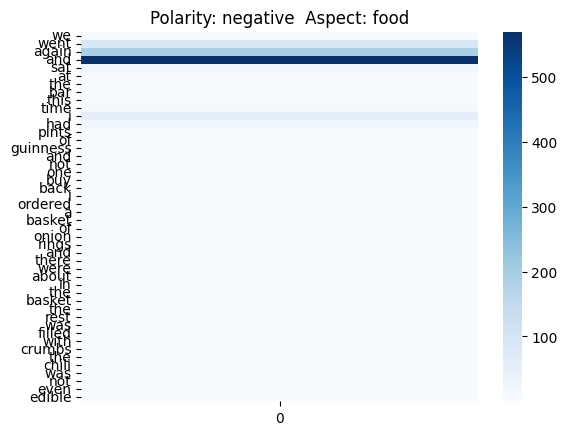

In [99]:
viz_attention(1, test_data, alpha)

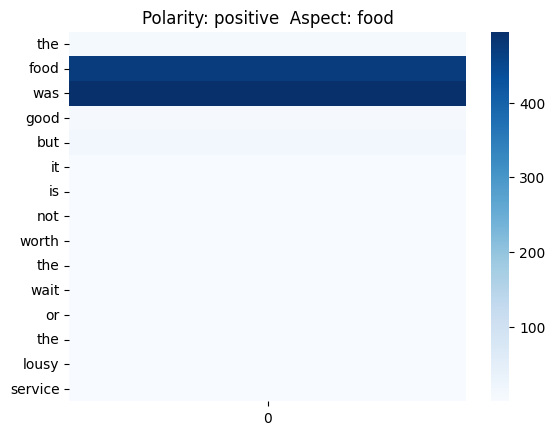

In [100]:
viz_attention(2, test_data, alpha)

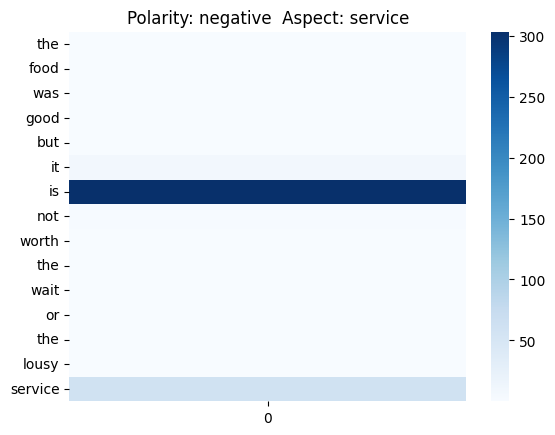

In [101]:
viz_attention(3, test_data, alpha)

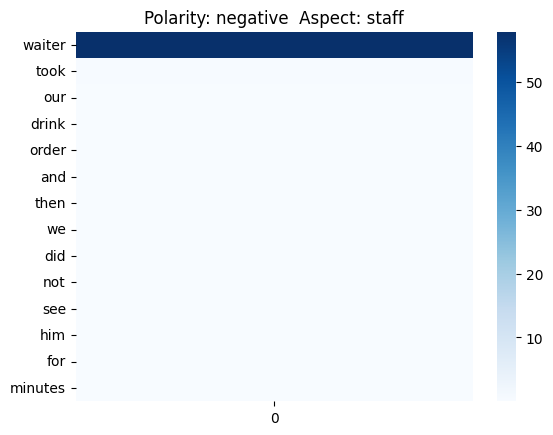

In [102]:
viz_attention(4, test_data, alpha)

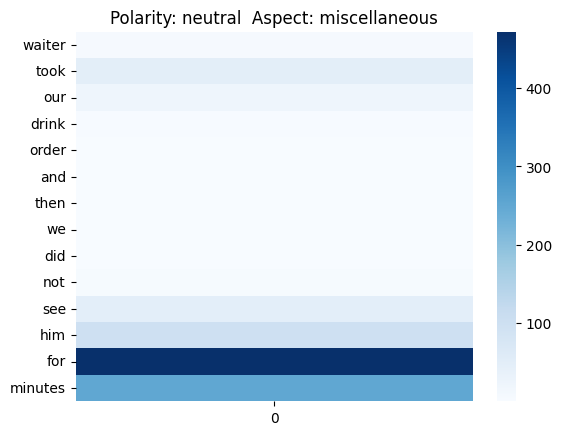

In [103]:
viz_attention(5, test_data, alpha)

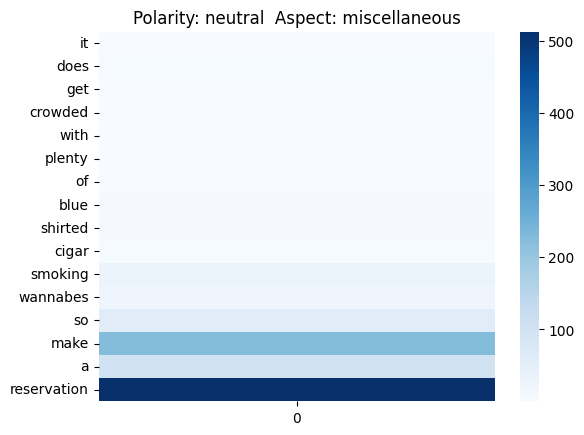

In [104]:
viz_attention(7, test_data, alpha)

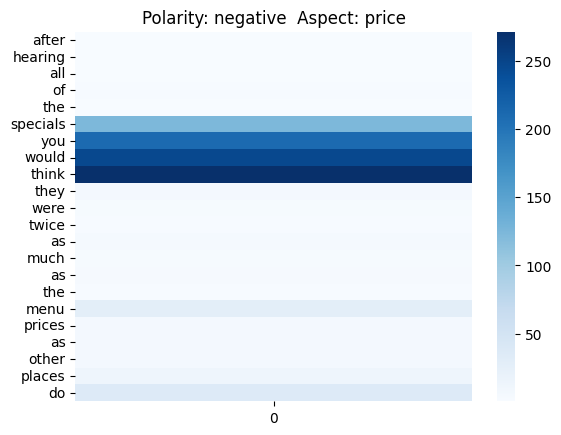

In [105]:
viz_attention(9, test_data, alpha)

---